In [1]:
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in data from the Nulisa assay
# which was sent to us by Bofei
df = pd.read_excel('../data/NULISA_for_upload.xlsx')
df.head()

,targetName,P08_C1_D1_BMA,P08_C1_D1_PB,P08_C7_D1_BMA,P08_C7_D1_PB,P24_C1_D1_BMA,P24_C1_D1_PB,P24_C7_D1_BMA,P24_C7_D1_PB,P12_C1_D1_BMA,...,IPC3,NC1,NC2,NC3,NC4,RNBMA_Plasma,RNPB_Plasma,SC1,SC2,SC3
0,AGER,8.098874,12.815814,10.048087,13.426360,10.186972,13.409686,9.607677,12.971496,10.819983,...,13.287857,0.000000,0.000000,0.000000,0.000000,14.652822,15.761617,13.515206,13.430871,13.215132
1,AGRP,7.261311,11.599770,9.653722,13.281680,9.498240,12.211211,10.164315,13.604866,9.289948,...,13.287857,4.197841,4.243510,0.000000,4.827565,12.537522,12.795884,13.320905,13.332838,13.281140
2,ANGPT1,11.176965,13.711416,11.570059,11.973600,11.134398,12.117352,10.437689,12.194923,9.876157,...,13.183936,6.291575,5.703534,6.492616,6.009174,12.041054,12.818809,13.341584,13.315648,13.046785
3,ANGPT2,8.961332,12.817818,9.927943,12.801492,11.676046,14.589588,11.971372,15.528098,9.929931,...,13.257715,0.000000,1.506642,2.048571,0.000000,12.311747,13.277203,13.408156,13.351494,13.179535
4,ANXA1,9.855022,11.558501,9.068268,11.336655,9.376385,9.848232,9.008491,9.886488,9.602541,...,13.287857,9.460188,9.281864,8.860607,8.714064,8.498531,10.190912,13.472023,13.352042,12.968113


In [3]:
# Transpose the df so that it easier to work with 
df.index = df['targetName']
df = df.iloc[:, 1:]
df = df.T
df

# select blood and bone marrow samples from the oral aza trial (these have _BMA or _PB in the title and lack 'RN')
df = df.loc[df.index.str.contains('_BMA') | df.index.str.contains('_PB'), :]
df = df.loc[~df.index.str.contains('RN'), :]
df.head()

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,TREM1,TREM2,VCAM1,VEGFA,VEGFC,VEGFD,VSNL1,VSTM1,WNT16,WNT7A
P08_C1_D1_BMA,8.098874,7.261311,11.176965,8.961332,9.855022,8.826391,10.476133,10.957482,6.862759,8.990968,...,8.726599,7.940766,9.272499,11.652502,10.575666,8.022063,9.163231,10.833751,9.306676,6.368683
P08_C1_D1_PB,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,13.143437,12.017396,12.941936,15.142156,13.385485,7.592040,11.853413,14.683010,12.931866,8.744185
P08_C7_D1_BMA,10.048087,9.653722,11.570059,9.927943,9.068268,9.235046,9.005682,11.481258,7.992722,9.794737,...,9.923594,9.151399,10.754465,11.196261,10.928972,7.842120,9.814674,11.318856,10.098527,7.128281
P08_C7_D1_PB,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,12.639026,12.237741,13.337745,14.208861,13.273854,7.704273,11.770859,11.012886,13.143388,8.900478
P24_C1_D1_BMA,10.186972,9.498240,11.134398,11.676046,9.376385,9.196032,7.792804,11.939582,9.500984,10.703933,...,10.474709,9.921123,11.156053,11.185332,11.645861,7.479362,9.699821,9.703087,9.618251,7.059484


In [4]:
# Add some useful details to the dataframe, this information is encoded in the sample name (index)
# and added to the df using for loops

samp = ['BMA' if 'BMA' in i else 'PB' for i in df.index]
df['sample_type'] = samp
del samp

timepoint = []
for i in df.index:
    if 'C1_D1' in i:
        timepoint.append('C1_D1')
    elif 'C7_D1' in i:
        timepoint.append('C7_D1')
    elif 'C12_D29' in i:
        timepoint.append('C12_D29')
df['timepoint'] = timepoint
del timepoint

pid = []
for i in df.index:
    e = i.replace('_BMA', '')
    e = e.replace('_PB', '')
    e = re.sub('_C'r'\d{1,2}_D\d{1,2}', '', e)
    e = e.replace('_', '')
    pid.append(e)
pid

df['pid'] = pid
del pid

In [5]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows=40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))
    
# Use the dictionaries to add clinical outcomes to the dataframe
df['diagnosis'] = df['pid'].map(diagnosis_dx)
df['outcome_6'] = df['pid'].map(outcome_C6_dx)
df['outcome_12'] = df['pid'].map(outcome_C12_dx)    


In [6]:
# Change the names of the outcome column to something simpler
df[['outcome_6', 'outcome_12']] = df[['outcome_6', 'outcome_12']].apply(lambda x: x.str.replace('responder_1', 'responder'))
df[['outcome_6', 'outcome_12']] = df[['outcome_6', 'outcome_12']].apply(lambda x: x.str.replace('non-responder_2', 'non_responder'))


In [7]:
# Create a new column which details the patient and timepoint
df['pid_tp'] = df['pid'] + '_' + df['timepoint'].str.replace('_', '')
df['pid_tp']

P08_C1_D1_BMA    P08_C1D1
P08_C1_D1_PB     P08_C1D1
P08_C7_D1_BMA    P08_C7D1
P08_C7_D1_PB     P08_C7D1
P24_C1_D1_BMA    P24_C1D1
                   ...   
P13_C7_D1_PB     P13_C7D1
P21_C1_D1_BMA    P21_C1D1
P21_C1_D1_PB     P21_C1D1
P21_C7_D1_BMA    P21_C7D1
P21_C7_D1_PB     P21_C7D1
Name: pid_tp, Length: 81, dtype: object

In [8]:
# Create a df which contains only blood samples
df_pb = df.loc[df.index.str.contains('PB'), :]
df_pb.index = df_pb.index.str.replace('_PB', '')
df_pb['pid_tp'] = df_pb['pid'].astype(str) + '_' + df_pb['timepoint'].str.replace('_', '')
print(df_pb.shape)
df_pb = df_pb.loc[(df_pb['timepoint'] == 'C1_D1') | (df_pb['timepoint'] == 'C7_D1'), :]
print(df_pb.shape)

(35, 254)
(34, 254)


<ipython-input-8-f64e428e1008>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pb['pid_tp'] = df_pb['pid'].astype(str) + '_' + df_pb['timepoint'].str.replace('_', '')


In [9]:
# Read in the pvalues from Jake
pval = pd.read_excel('../data/2024_11_08_pvalues_from_Jake.xlsx', sheet_name= 'Slide3')
print(pval.shape)
pval = pval.loc[pval['p_values'] <= 0.05, :]
# Swap two rows to make for easier plotting
print(pval.shape)
pval

(245, 2)
(16, 2)


,Cluster_Cell_type,p_values
0,FLT3LG,0.0036
1,TNFSF13,0.0061
2,IL17B,0.0084
3,CCL13,0.0108
4,CXCL5,0.0140
5,CCL15,0.0157
6,TNFSF12,0.0194
7,FGF2,0.0197
8,CXCL11,0.0215
9,THPO,0.0245


In [10]:
def add_balanced_jitter(df, time_column, jitter_amount=0.25):
    """
    Add balanced jitter to time points where approximately half the points are above
    and half are below each time value.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    time_column (str): Name of the column containing time values
    jitter_amount (float): Amount of jitter to apply
    
    Returns:
    pandas.Series: Series containing jittered time values
    """
    # Create a copy to avoid modifying the original
    result = df[time_column].copy()
    
    # Process each unique time point separately
    for time_value in df[time_column].unique():
        # Get indices for this time point
        mask = df[time_column] == time_value
        n_points = mask.sum()
        
        # Generate balanced jitter values
        n_positive = n_points // 2
        n_negative = n_points - n_positive
        
        # Create positive and negative jitter values
        positive_jitter = np.random.uniform(0, jitter_amount, size=n_positive)
        negative_jitter = np.random.uniform(-jitter_amount, 0, size=n_negative)
        
        # Combine and shuffle the jitter values
        combined_jitter = np.concatenate([positive_jitter, negative_jitter])
        np.random.shuffle(combined_jitter)
        
        # Apply jitter to this time point
        result.loc[mask] = time_value + combined_jitter
    
    return result


In [11]:
df_pb

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,VSTM1,WNT16,WNT7A,sample_type,timepoint,pid,diagnosis,outcome_6,outcome_12,pid_tp
P08_C1_D1,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,14.683010,12.931866,8.744185,PB,C1_D1,P08,MDS,non_responder,non_responder,P08_C1D1
P08_C7_D1,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,11.012886,13.143388,8.900478,PB,C7_D1,P08,MDS,non_responder,non_responder,P08_C7D1
P24_C1_D1,13.409686,12.211211,12.117352,14.589588,9.848232,10.399768,10.552040,12.523015,12.473277,13.134511,...,11.279987,12.565671,8.744706,PB,C1_D1,P24,AML,non_responder,NaN,P24_C1D1
P24_C7_D1,12.971496,13.604866,12.194923,15.528098,9.886488,10.453888,10.212944,12.194522,12.178838,13.449840,...,10.086519,12.867314,9.052809,PB,C7_D1,P24,AML,non_responder,NaN,P24_C7D1
P12_C1_D1,13.698245,12.930173,12.565802,13.068282,9.113249,10.701452,13.841984,12.688355,12.596144,14.120495,...,11.916969,12.884989,9.620725,PB,C1_D1,P12,MDS,responder,responder,P12_C1D1
P12_C7_D1,13.972684,14.652388,13.903779,12.825494,9.158899,10.342438,15.547902,12.540153,10.867731,13.872861,...,8.459874,13.044832,10.165778,PB,C7_D1,P12,MDS,responder,responder,P12_C7D1
P04_C1_D1,13.202248,12.799180,11.184085,13.495764,9.587354,9.972133,6.338712,12.494508,10.816165,13.212585,...,14.101869,12.684559,8.967549,PB,C1_D1,P04,AML,responder,non_responder,P04_C1D1
P04_C7_D1,11.483475,13.588755,15.166637,12.762694,9.003599,10.488438,16.030052,11.906930,10.458220,12.582448,...,10.490137,12.431912,10.015726,PB,C7_D1,P04,AML,responder,non_responder,P04_C7D1
P03_C1_D1,13.836740,12.825042,12.486342,13.045114,10.678130,11.410011,12.055060,12.184086,10.315101,13.280309,...,12.724190,13.024659,9.760402,PB,C1_D1,P03,MDS,responder,responder,P03_C1D1
P03_C7_D1,13.629345,13.055261,12.687346,13.191082,10.282887,11.752607,13.527198,12.043008,10.914491,12.790688,...,12.576448,13.079476,10.034908,PB,C7_D1,P03,MDS,responder,responder,P03_C7D1


In [12]:
# Add timepoints to the graph to allow for easy plotting
tp = {'C1D1' : 1,  'C7D1': 2}
df_pb['time'] = df_pb['timepoint'].str.replace('_', '').map(tp)
df_pb['time1'] = add_balanced_jitter(df_pb, 'time', jitter_amount=0.05)

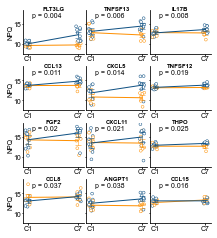

In [13]:
# Define color dictionary
color_dict = {'non_responder':'#fe9003', 'responder':'#115284', 'Healthy': 'grey'}

plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text


figure_list = [x for x in pval['Cluster_Cell_type'][:12]]
figure_list.remove('CCL15') # Move CCL15 to the end of figure_list as this goes down in responders
figure_list.append('CCL15')


fig, ax = plt.subplots(nrows=4, ncols=3, figsize = (5 * (1.5/2.4), 3.425))
axs_flatten = ax.flatten()

for x, ax in enumerate(axs_flatten):
    if x >= 0:
        ax.scatter(x = df_pb.loc[:,'time1'], y = df_pb.loc[:, figure_list[x]], 
                  facecolor = 'white', edgecolor = df_pb.loc[:,'outcome_6'].map(color_dict), lw = 0.5, s =8)
        
        sns.lineplot(data=df_pb, 
            x='time', 
            y=df_pb.loc[:, figure_list[x]],
            errorbar=('sd', 0.5),
            err_style='bars',
            err_kws={'linewidth': 0.5, 'capsize':3, 'capthick': 0.5},# combines errorbar type and capsize
            legend=False,
            hue='outcome_6',
            palette=color_dict, 
            linewidth=1, 
            ax=ax)

        #ax.scatter(x = stars['time1'], y = stars[figure_list[x]], s = 3, facecolor = 'white', lw = 0.5,  edgecolor = 'hotpink')

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 7.5, top = 18.5)
        e = str(figure_list[x])
        ax.set_yticks([ 10, 15])
        ax.set_yticklabels(['10', '15'])
        
        ax.set_title(str(e), fontsize = 6, fontweight = 'bold', y = 0.85)
        ax.set_xlabel('')
            
        if x % 3 == 0:
            ax.set_ylabel('NPQ', fontsize = 7, labelpad = 0.1)
            ax.set_xticks([1, 2])
            ax.set_xticklabels(['0', '168'], rotation = 0, fontsize = 7) 
        else:
            ax.set_ylabel('')
            ax.set_xticks([1, 2])
            ax.set_xticklabels(['0', '168'], rotation = 0, fontsize = 7)
            ax.set_yticklabels([], rotation = 0, fontsize = 7) 
               
        if x >=12:
            ax.set_xlabel('Time (days)', fontsize = 7, labelpad = 1)

        ax.set_xticklabels(['C1', 'C7'])
        ax.tick_params(axis='both', labelsize=7, pad = 0.15, length = 1.5)
        
        # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.15 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.175 * (ymax - ymin)  # 5% from top
        
        # Add the p-value to each graph
        text = pval.loc[pval['Cluster_Cell_type'] == figure_list[x], 'p_values'].values[0]

        # Try this instead
        text = round(float(text), 3)
        ax.text(x=x_pos, y=y_pos, s=f'p = {text}', fontsize=7)
        
      
        
plt.tight_layout(h_pad= 0.1, w_pad=0.1)
#fig.savefig('../graphs_for_figure/blood_figure_4_2.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600, 
 #      format='pdf', backend='pdf')